# <center>Speech Stress Recognition with Fine-Tuned Wav2Vec2.0</center>

We fine-tune **Wav2Vec2.0** (`facebook/wav2vec2-base`) on emotional-speech datasets to detect
**stress from voice**. For every audio clip the model outputs:

* **Stress Level** — `Low`, `Moderate`, or `High`
* **Confidence** — how sure the model is (0–100%)
* **Positivity** — how positive/negative the tone is (0–100)

### Datasets
RAVDESS, CREMA-D, TESS, SAVEE — same as classic SER projects, but each emotion is re-labeled
onto two simpler dimensions:

| Emotion | Stress | Positivity |
|---|---|---|
| angry, fear, disgust | High | Negative |
| sad, surprise | Moderate | Neutral/Negative |
| neutral | Low | Neutral |
| calm, happy | Low | Positive |


## 1. Setup

In [16]:
# !pip install -q transformers torch librosa soundfile

import os
import warnings

import numpy as np
import pandas as pd
import librosa

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings("ignore")
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


Using device: cuda
NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 2. Data preparation

Build one `(path, emotion)` dataframe from all four datasets, then map each emotion to a
`stress_level` and `positivity` label. Update the paths below to your data location.

In [17]:
Ravdess = "D:\\Ravdess\\audio_speech_actors_01-24"
Crema   = "D:\CremaD\AudioWAV"
Tess    = "D:\TESS\TESS Toronto emotional speech set data\TESS Toronto emotional speech set data"
Savee   = "D:\Savee\ALL"

RAVDESS_CODES = {1: "neutral", 2: "calm", 3: "happy", 4: "sad", 5: "angry", 6: "fear", 7: "disgust", 8: "surprise"}
CREMA_CODES = {"SAD": "sad", "ANG": "angry", "DIS": "disgust", "FEA": "fear", "HAP": "happy", "NEU": "neutral"}
SAVEE_CODES = {"a": "angry", "d": "disgust", "f": "fear", "h": "happy", "n": "neutral", "sa": "sad", "su": "surprise"}


def load_ravdess(Ravdess):
    rows = []
    for actor in os.listdir(Ravdess):
        for file in os.listdir(os.path.join(Ravdess, actor)):
            code_num = int(file.split("-")[2])
            rows.append((os.path.join(Ravdess, actor, file), RAVDESS_CODES[code_num]))
    return rows


def load_crema(Crema):
    rows = []
    for file in os.listdir(Crema):
        emotion = CREMA_CODES.get(file.split("_")[2])
        if emotion:
            rows.append((os.path.join(Crema, file), emotion))
    return rows


def load_tess(Tess):
    rows = []
    for folder in os.listdir(Tess):
        emotion = folder.split("_")[-1].lower()
        emotion = "surprise" if emotion in ("ps", "pleasant_surprised") else emotion
        for file in os.listdir(os.path.join(Tess, folder)):
            rows.append((os.path.join(Tess, folder, file), emotion))
    return rows


def load_savee(Savee):
    rows = []
    for file in os.listdir(Savee):
        letters = "".join(c for c in file.split("_")[-1] if c.isalpha()).lower()
        key = letters[:2] if letters[:2] in SAVEE_CODES else letters[:1]
        emotion = SAVEE_CODES.get(key)
        if emotion:
            rows.append((os.path.join(Savee, file), emotion))
    return rows


rows = []
for loader, root in [(load_ravdess, Ravdess), (load_crema, Crema), (load_tess, Tess), (load_savee, Savee)]:
    if os.path.isdir(root):
        rows += loader(root)
    else:
        print("Path not found, skipping:", root)

data_df = pd.DataFrame(rows, columns=["path", "emotion"])
print("Total samples:", len(data_df))
data_df.tail()


Total samples: 12162


,path,emotion
12157,D:\Savee\ALL\KL_su11.wav,surprise
12158,D:\Savee\ALL\KL_su12.wav,surprise
12159,D:\Savee\ALL\KL_su13.wav,surprise
12160,D:\Savee\ALL\KL_su14.wav,surprise
12161,D:\Savee\ALL\KL_su15.wav,surprise


In [18]:
EMOTION_TO_STRESS = {
    "angry": "High", "fear": "High", "disgust": "High",
    "sad": "Moderate", "surprise": "Moderate","surprised": "Moderate",
    "neutral": "Low", "calm": "Low", "happy": "Low",
}
EMOTION_TO_POSITIVITY = {
    "angry": "Negative", "fear": "Negative", "disgust": "Negative", "sad": "Negative",
    "surprise": "Neutral", "neutral": "Neutral",
    "calm": "Positive", "happy": "Positive","surprised": "Neutral"
}

STRESS_LABELS = ["Low", "Moderate", "High"]
POSITIVITY_LABELS = ["Negative", "Neutral", "Positive"]
POSITIVITY_SCORE = {"Negative": 0.0, "Neutral": 50.0, "Positive": 100.0}

data_df["stress_level"] = data_df["emotion"].map(EMOTION_TO_STRESS)
data_df["positivity"] = data_df["emotion"].map(EMOTION_TO_POSITIVITY)
data_df.head()


,path,emotion,stress_level,positivity
0,D:\Ravdess\audio_speech_actors_01-24\Actor_01\...,neutral,Low,Neutral
1,D:\Ravdess\audio_speech_actors_01-24\Actor_01\...,neutral,Low,Neutral
2,D:\Ravdess\audio_speech_actors_01-24\Actor_01\...,neutral,Low,Neutral
3,D:\Ravdess\audio_speech_actors_01-24\Actor_01\...,neutral,Low,Neutral
4,D:\Ravdess\audio_speech_actors_01-24\Actor_01\...,calm,Low,Positive


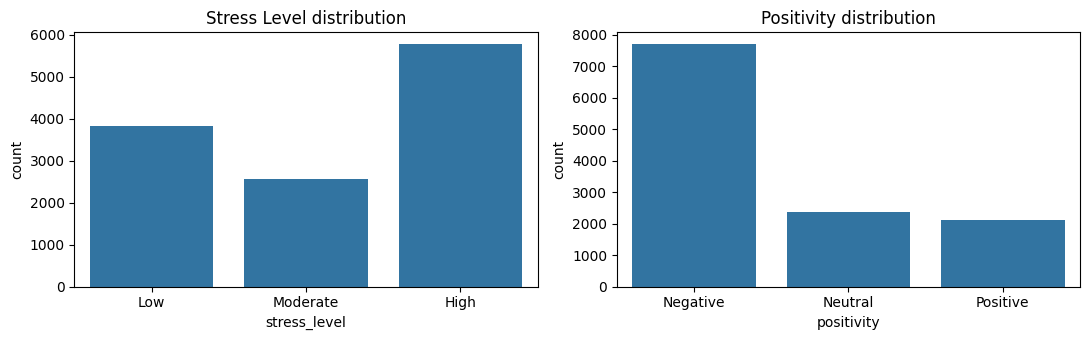

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.countplot(x="stress_level", data=data_df, order=STRESS_LABELS, ax=axes[0])
axes[0].set_title("Stress Level distribution")
sns.countplot(x="positivity", data=data_df, order=POSITIVITY_LABELS, ax=axes[1])
axes[1].set_title("Positivity distribution")
plt.tight_layout()
plt.show()


## 3. Train / validation / test split

In [20]:
print(data_df["stress_level"].isna().sum())

print(data_df[data_df["stress_level"].isna()]["emotion"].unique())


0
<StringArray>
[]
Length: 0, dtype: str


In [6]:
train_df, temp_df = train_test_split(data_df, test_size=0.2, random_state=42, stratify=data_df["stress_level"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["stress_level"])
print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))


Train: 9729  Val: 1216  Test: 1217


## 4. Dataset & feature extractor

Audio is resampled to 16kHz and padded/truncated to 4 seconds so Wav2Vec2 can process fixed-size
batches.

In [21]:
MODEL_NAME = "facebook/wav2vec2-base"
SAMPLE_RATE = 16000
MAX_LENGTH = SAMPLE_RATE * 4  # 4 seconds

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)


class StressDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        speech, _ = librosa.load(row["path"], sr=SAMPLE_RATE)
        speech = librosa.util.fix_length(speech, size=MAX_LENGTH)

        input_values = feature_extractor(speech, sampling_rate=SAMPLE_RATE, return_tensors="pt").input_values[0]
        stress_idx = STRESS_LABELS.index(row["stress_level"])
        positivity_idx = POSITIVITY_LABELS.index(row["positivity"])
        return input_values, stress_idx, positivity_idx


def collate_fn(batch):
    input_values, stress_idx, positivity_idx = zip(*batch)
    return torch.stack(input_values), torch.tensor(stress_idx), torch.tensor(positivity_idx)


BATCH_SIZE = 8
train_loader = DataLoader(StressDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(StressDataset(val_df), batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(StressDataset(test_df), batch_size=BATCH_SIZE, collate_fn=collate_fn)


## 5. Model — Wav2Vec2 backbone + two classification heads

The CNN feature-encoder is frozen; the transformer layers and both heads are fine-tuned. The
model returns logits for stress (3 classes) and positivity (3 classes) from the same pooled
embedding.

In [22]:
class StressClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.wav2vec2 = Wav2Vec2Model.from_pretrained(MODEL_NAME)
        self.wav2vec2.feature_extractor._freeze_parameters()

        hidden = self.wav2vec2.config.hidden_size
        self.stress_head = nn.Linear(hidden, len(STRESS_LABELS))
        self.positivity_head = nn.Linear(hidden, len(POSITIVITY_LABELS))

    def forward(self, input_values):
        hidden_states = self.wav2vec2(input_values).last_hidden_state
        pooled = hidden_states.mean(dim=1)  # average over time
        return self.stress_head(pooled), self.positivity_head(pooled)


model = StressClassifier().to(DEVICE)
print("Model ready.")


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 41929.13it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready.


NameError: name 'model' is not defined

## 6. Training

Total loss = cross-entropy(stress) + cross-entropy(positivity), so the shared backbone learns
useful features for both tasks at once.

In [23]:
def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, stress_correct, pos_correct, n = 0.0, 0, 0, 0
    with torch.set_grad_enabled(training):
        for input_values, stress_true, pos_true in loader:
            input_values, stress_true, pos_true = input_values.to(DEVICE), stress_true.to(DEVICE), pos_true.to(DEVICE)

            stress_logits, pos_logits = model(input_values)
            loss = F.cross_entropy(stress_logits, stress_true) + F.cross_entropy(pos_logits, pos_true)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(stress_true)
            stress_correct += (stress_logits.argmax(-1) == stress_true).sum().item()
            pos_correct += (pos_logits.argmax(-1) == pos_true).sum().item()
            n += len(stress_true)

    return total_loss / n, stress_correct / n, pos_correct / n


In [34]:
EPOCHS = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)

best_val_loss = float("inf")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_stress_acc, train_pos_acc = run_epoch(train_loader, optimizer)
    val_loss, val_stress_acc, val_pos_acc = run_epoch(val_loader)

    print(f"Epoch {epoch:02d} | loss {train_loss:.3f}/{val_loss:.3f} | "
          f"stress acc {train_stress_acc:.2f}/{val_stress_acc:.2f} | "
          f"positivity acc {train_pos_acc:.2f}/{val_pos_acc:.2f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "wav2vec2_stress_best.pt")


Epoch 01 | loss 1.202/0.896 | stress acc 0.71/0.78 | positivity acc 0.78/0.86
Epoch 02 | loss 0.718/0.766 | stress acc 0.83/0.81 | positivity acc 0.89/0.88
Epoch 03 | loss 0.577/0.724 | stress acc 0.86/0.82 | positivity acc 0.92/0.89
Epoch 04 | loss 0.440/0.711 | stress acc 0.89/0.84 | positivity acc 0.94/0.90
Epoch 05 | loss 0.359/0.727 | stress acc 0.90/0.84 | positivity acc 0.96/0.90
Epoch 06 | loss 0.325/0.777 | stress acc 0.92/0.83 | positivity acc 0.96/0.89
Epoch 07 | loss 0.259/0.863 | stress acc 0.93/0.84 | positivity acc 0.97/0.91
Epoch 08 | loss 0.235/0.826 | stress acc 0.94/0.84 | positivity acc 0.97/0.89
Epoch 09 | loss 0.218/0.713 | stress acc 0.95/0.85 | positivity acc 0.97/0.90
Epoch 10 | loss 0.175/0.903 | stress acc 0.95/0.85 | positivity acc 0.98/0.90


## 7. Evaluation on the test set

In [24]:
model.load_state_dict(torch.load(r"C:\Users\ghimi\OneDrive\Documents\Programming\project\voiceModel\wav2vec2_stress_best.pt", map_location=DEVICE))
model.eval()

stress_preds, stress_true, pos_preds, pos_true = [], [], [], []
with torch.no_grad():
    for input_values, s_true, p_true in test_loader:
        s_logits, p_logits = model(input_values.to(DEVICE))
        stress_preds += s_logits.argmax(-1).cpu().tolist()
        stress_true += s_true.tolist()
        pos_preds += p_logits.argmax(-1).cpu().tolist()
        pos_true += p_true.tolist()

print("=== Stress Level ===")
print(classification_report(stress_true, stress_preds, target_names=STRESS_LABELS))
print("=== Positivity ===")
print(classification_report(pos_true, pos_preds, target_names=POSITIVITY_LABELS))


ImportError: DLL load failed while importing _dynfunc: An Application Control policy has blocked this file.

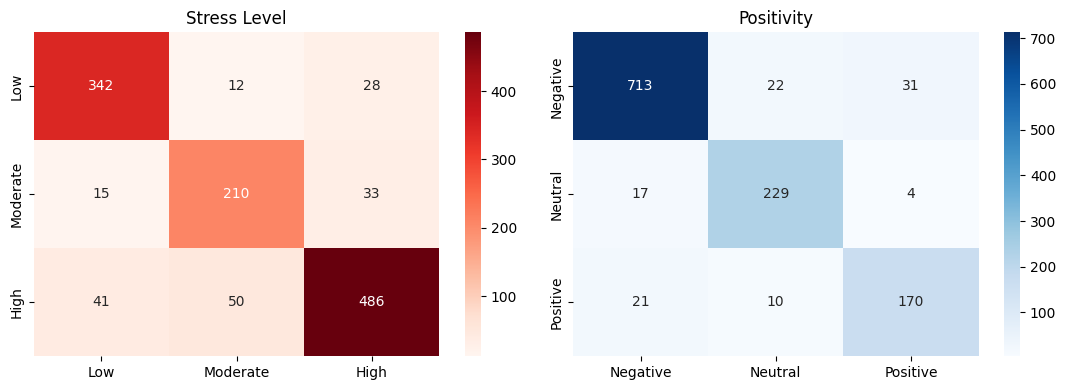

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(stress_true, stress_preds), annot=True, fmt="d",
            xticklabels=STRESS_LABELS, yticklabels=STRESS_LABELS, ax=axes[0], cmap="Reds")
axes[0].set_title("Stress Level")
sns.heatmap(confusion_matrix(pos_true, pos_preds), annot=True, fmt="d",
            xticklabels=POSITIVITY_LABELS, yticklabels=POSITIVITY_LABELS, ax=axes[1], cmap="Blues")
axes[1].set_title("Positivity")
plt.tight_layout()
plt.show()


## 8. Inference — predict stress from a new voice clip

`predict_stress(audio_path)` returns the three requested outputs: `stress_level`, `confidence`
(%), and `positivity` (0–100).

In [15]:

def predict_stress(audio_path):
    model.eval()
    speech, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
    speech = librosa.util.fix_length(speech, size=MAX_LENGTH)
    input_values = feature_extractor(speech, sampling_rate=SAMPLE_RATE, return_tensors="pt").input_values.to(DEVICE)

    with torch.no_grad():
        stress_logits, pos_logits = model(input_values)
        stress_probs = F.softmax(stress_logits, dim=-1)[0].cpu().numpy()
        pos_probs = F.softmax(pos_logits, dim=-1)[0].cpu().numpy()

    stress_idx = int(stress_probs.argmax())
    positivity_score = float(sum(p * POSITIVITY_SCORE[l] for p, l in zip(pos_probs, POSITIVITY_LABELS)))

    return {
        "stress_level": STRESS_LABELS[stress_idx],
        "confidence": round(float(stress_probs[stress_idx]) * 100, 2),
        "positivity": round(positivity_score, 2),
    }


 


In [16]:
predict_stress(r"C:\Users\ghimi\Downloads\Recording.wav")

ImportError: DLL load failed while importing _dynfunc: An Application Control policy has blocked this file.

In [27]:
def show_stress_report(audio_path):
    result = predict_stress(audio_path)
    print(f"File: {audio_path}")
    print(f"Stress Level : {result['stress_level']}")
    print(f"Confidence   : {result['confidence']}%")
    print(f"Positivity   : {result['positivity']}/100")
    return result


# Demo on a few test clips
for p in test_df["path"].sample(min(3, len(test_df)), random_state=42):
    show_stress_report(p)
    print()


File: D:\CremaD\AudioWAV\1072_IWL_FEA_XX.wav
Stress Level : High
Confidence   : 98.77%
Positivity   : 0.28/100

File: D:\CremaD\AudioWAV\1084_MTI_HAP_XX.wav
Stress Level : High
Confidence   : 57.54%
Positivity   : 44.37/100

File: D:\CremaD\AudioWAV\1064_WSI_NEU_XX.wav
Stress Level : Low
Confidence   : 98.04%
Positivity   : 48.99/100



## Notes

* Stress/positivity labels are derived from acted-emotion datasets, so treat predictions as an
  indicative signal, not a clinical measurement.
* To improve accuracy: unfreeze more Wav2Vec2 layers, use `wav2vec2-large`, add class weights
  for the underrepresented `Moderate` class, or fine-tune further on real stress-specific audio.
